<a href="https://www.kaggle.com/code/sonawanelalitsunil/oral-cancer-risk-prediction-ml-100?scriptVersionId=226733244" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/oral-cancer-prediction-dataset/oral_cancer_prediction_dataset.csv


## Title: Oral Cancer Risk Prediction Dataset

#### Description: This dataset contains medical and lifestyle factors related to oral cancer, including patient demographics, symptoms, genetic markers, and environmental exposures. It can be used for predictive modeling, risk assessment, and early diagnosis research.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [4]:
df =pd.read_csv('/kaggle/input/oral-cancer-prediction-dataset/oral_cancer_prediction_dataset.csv')

In [5]:
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [6]:
df.tail()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
84917,84918,USA,46,Male,Yes,No,No,No,No,Yes,...,No,Yes,0.000000,0,No Treatment,100.000000,0.0,0,Yes,No
84918,84919,USA,41,Male,Yes,Yes,No,No,No,No,...,Yes,Yes,0.000000,0,No Treatment,100.000000,0.0,0,Yes,No
84919,84920,Taiwan,72,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,4.777394,1,Surgery,85.633426,81352.5,90,No,Yes
84920,84921,Japan,67,Male,Yes,No,No,No,No,No,...,Yes,No,0.000000,0,No Treatment,100.000000,0.0,0,Yes,No
84921,84922,Pakistan,75,Male,Yes,No,No,Yes,Yes,No,...,No,No,0.000000,0,No Treatment,100.000000,0.0,0,No,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  object 
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  object 
 4   Tobacco Use                               84922 non-null  object 
 5   Alcohol Consumption                       84922 non-null  object 
 6   HPV Infection                             84922 non-null  object 
 7   Betel Quid Use                            84922 non-null  object 
 8   Chronic Sun Exposure                      84922 non-null  object 
 9   Poor Oral Hygiene                         84922 non-null  object 
 10  Diet (Fruits & Vegetables Intake) 

In [8]:
df.describe()

,ID,Age,Tumor Size (cm),Cancer Stage,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year)
count,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000
mean,42461.500000,54.509444,1.747294,1.118756,79.503364,39109.881244,52.028391
std,24515.014117,10.014839,2.028199,1.340418,26.483746,44710.687054,60.389796
min,1.000000,15.000000,0.000000,0.000000,10.000750,0.000000,0.000000
25%,21231.250000,48.000000,0.000000,0.000000,65.233425,0.000000,0.000000
50%,42461.500000,55.000000,0.000000,0.000000,100.000000,0.000000,0.000000
75%,63691.750000,61.000000,3.480075,2.000000,100.000000,76468.437500,104.000000
max,84922.000000,101.000000,5.999899,4.000000,100.000000,159988.000000,179.000000


In [9]:
df.isnull().sum()

ID                                          0
Country                                     0
Age                                         0
Gender                                      0
Tobacco Use                                 0
Alcohol Consumption                         0
HPV Infection                               0
Betel Quid Use                              0
Chronic Sun Exposure                        0
Poor Oral Hygiene                           0
Diet (Fruits & Vegetables Intake)           0
Family History of Cancer                    0
Compromised Immune System                   0
Oral Lesions                                0
Unexplained Bleeding                        0
Difficulty Swallowing                       0
White or Red Patches in Mouth               0
Tumor Size (cm)                             0
Cancer Stage                                0
Treatment Type                              0
Survival Rate (5-Year, %)                   0
Cost of Treatment (USD)           

In [10]:
df.duplicated().sum()

0

In [11]:
df.corr

<bound method DataFrame.corr of           ID       Country  Age  Gender Tobacco Use Alcohol Consumption  \
0          1         Italy   36  Female         Yes                 Yes   
1          2         Japan   64    Male         Yes                 Yes   
2          3            UK   37  Female          No                 Yes   
3          4     Sri Lanka   55    Male         Yes                 Yes   
4          5  South Africa   68    Male          No                  No   
...      ...           ...  ...     ...         ...                 ...   
84917  84918           USA   46    Male         Yes                  No   
84918  84919           USA   41    Male         Yes                 Yes   
84919  84920        Taiwan   72    Male         Yes                 Yes   
84920  84921         Japan   67    Male         Yes                  No   
84921  84922      Pakistan   75    Male         Yes                  No   

      HPV Infection Betel Quid Use Chronic Sun Exposure Poor Oral H

In [12]:
df.dtypes

ID                                            int64
Country                                      object
Age                                           int64
Gender                                       object
Tobacco Use                                  object
Alcohol Consumption                          object
HPV Infection                                object
Betel Quid Use                               object
Chronic Sun Exposure                         object
Poor Oral Hygiene                            object
Diet (Fruits & Vegetables Intake)            object
Family History of Cancer                     object
Compromised Immune System                    object
Oral Lesions                                 object
Unexplained Bleeding                         object
Difficulty Swallowing                        object
White or Red Patches in Mouth                object
Tumor Size (cm)                             float64
Cancer Stage                                  int64
Treatment Ty

In [13]:
df.columns

Index(['ID', 'Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

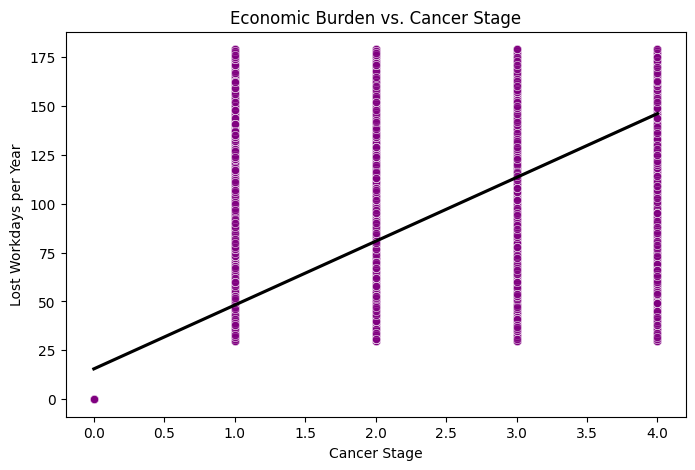

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Cancer Stage', y='Economic Burden (Lost Workdays per Year)', color='purple', alpha=0.7)
sns.regplot(data=df, x='Cancer Stage', y='Economic Burden (Lost Workdays per Year)', scatter=False, color='black')
plt.title('Economic Burden vs. Cancer Stage')
plt.xlabel('Cancer Stage')
plt.ylabel('Lost Workdays per Year')
plt.show()

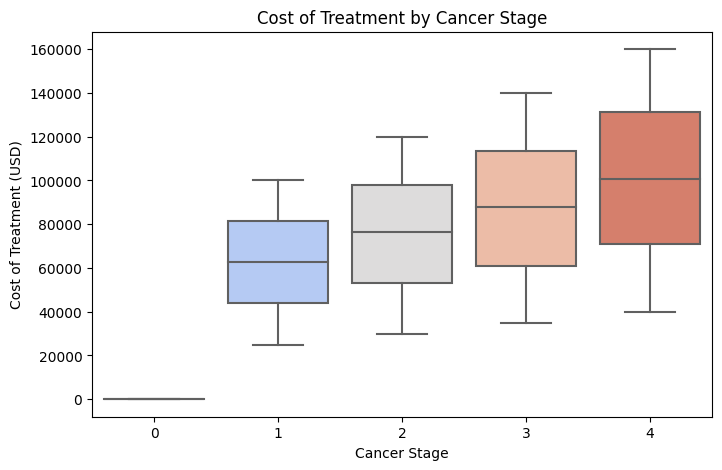

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Cancer Stage', y='Cost of Treatment (USD)', palette='coolwarm')
plt.title('Cost of Treatment by Cancer Stage')
plt.xlabel('Cancer Stage')
plt.ylabel('Cost of Treatment (USD)')
plt.show()

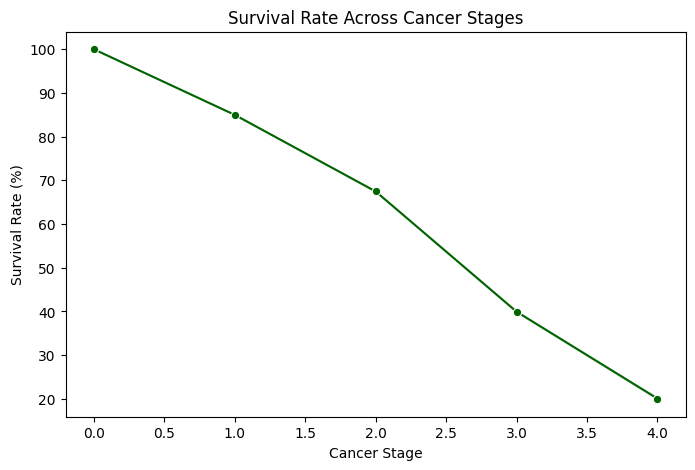

In [16]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='Cancer Stage', y='Survival Rate (5-Year, %)', marker='o', color='darkgreen')
plt.title('Survival Rate Across Cancer Stages')
plt.xlabel('Cancer Stage')
plt.ylabel('Survival Rate (%)')
plt.show()

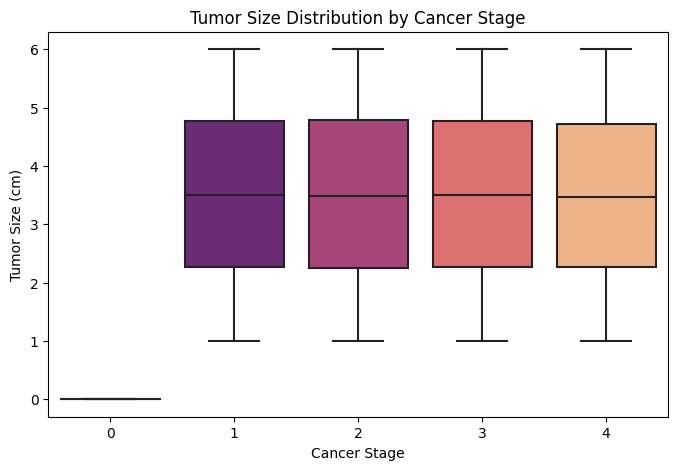

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Cancer Stage', y='Tumor Size (cm)', palette='magma')
plt.title('Tumor Size Distribution by Cancer Stage')
plt.xlabel('Cancer Stage')
plt.ylabel('Tumor Size (cm)')
plt.show()

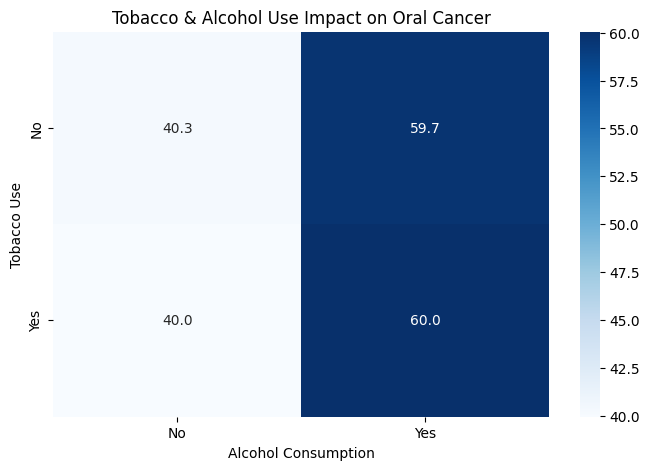

In [18]:
plt.figure(figsize=(8, 5))
sns.heatmap(pd.crosstab(df['Tobacco Use'], df['Alcohol Consumption'], normalize='index') * 100, annot=True, cmap='Blues', fmt='.1f')
plt.title('Tobacco & Alcohol Use Impact on Oral Cancer')
plt.xlabel('Alcohol Consumption')
plt.ylabel('Tobacco Use')
plt.show()

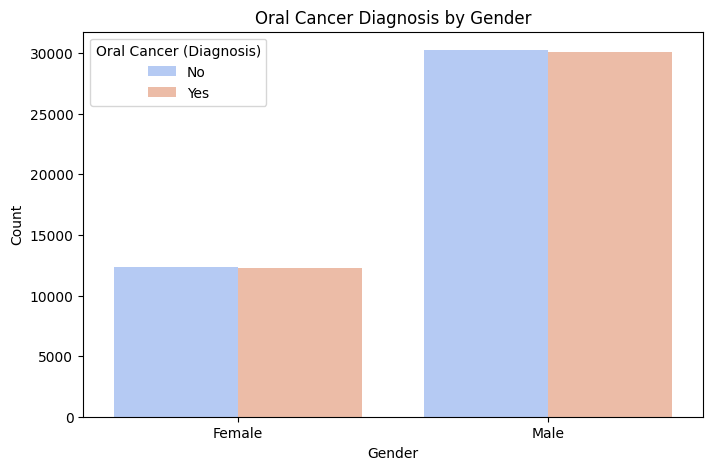

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='Oral Cancer (Diagnosis)', palette='coolwarm')
plt.title('Oral Cancer Diagnosis by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

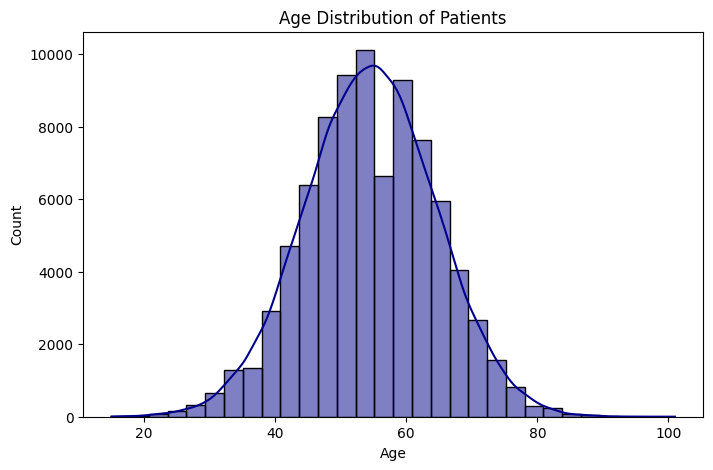

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='darkblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, confusion_matrix

In [22]:
# Define target variable and features
target = 'Oral Cancer (Diagnosis)'
features = [col for col in df.columns if col != target]

In [23]:
# Handle categorical variables using Label Encoding
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [24]:
# Split dataset into training and testing sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

In [27]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Logistic Regression Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8560
           1       1.00      1.00      1.00      8425

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985

--------------------------------------------------
Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8560
           1       1.00      1.00      1.00      8425

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985

--------------------------------------------------
Gradient Boosting Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8560
           1       1.00      1.0

In [28]:
# Display accuracy of all models
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print(results_df)

                    Model  Accuracy
0     Logistic Regression  1.000000
1           Random Forest  1.000000
2       Gradient Boosting  1.000000
3  Support Vector Machine  1.000000
5           Decision Tree  1.000000
6             Naive Bayes  1.000000
4     K-Nearest Neighbors  0.993936


In [29]:
results = {}
auc_scores = {}
f1_scores = {}
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    accuracy = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    results[name] = accuracy
    auc_scores[name] = auc
    f1_scores[name] = f1
    conf_matrices[name] = conf_matrix
    
    print(f"{name} Accuracy: {accuracy:.2f}%")
    print(f"AUC-ROC Score: {auc:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Logistic Regression Accuracy: 100.00%
AUC-ROC Score: 1.00
F1 Score: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8560
           1       1.00      1.00      1.00      8425

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985

--------------------------------------------------
Random Forest Accuracy: 100.00%
AUC-ROC Score: 1.00
F1 Score: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8560
           1       1.00      1.00      1.00      8425

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985

--------------------------------------------------
Gradient Boosting Accuracy: 100.00%
AUC-ROC Score: 1.00
F1 Score: 1.00
              precision    recall

                    Model  Accuracy (%)   AUC-ROC  F1 Score
0     Logistic Regression    100.000000  1.000000   1.00000
1           Random Forest    100.000000  1.000000   1.00000
2       Gradient Boosting    100.000000  1.000000   1.00000
3  Support Vector Machine    100.000000  1.000000   1.00000
5           Decision Tree    100.000000  1.000000   1.00000
6             Naive Bayes    100.000000  1.000000   1.00000
4     K-Nearest Neighbors     99.393583  0.999038   0.99385


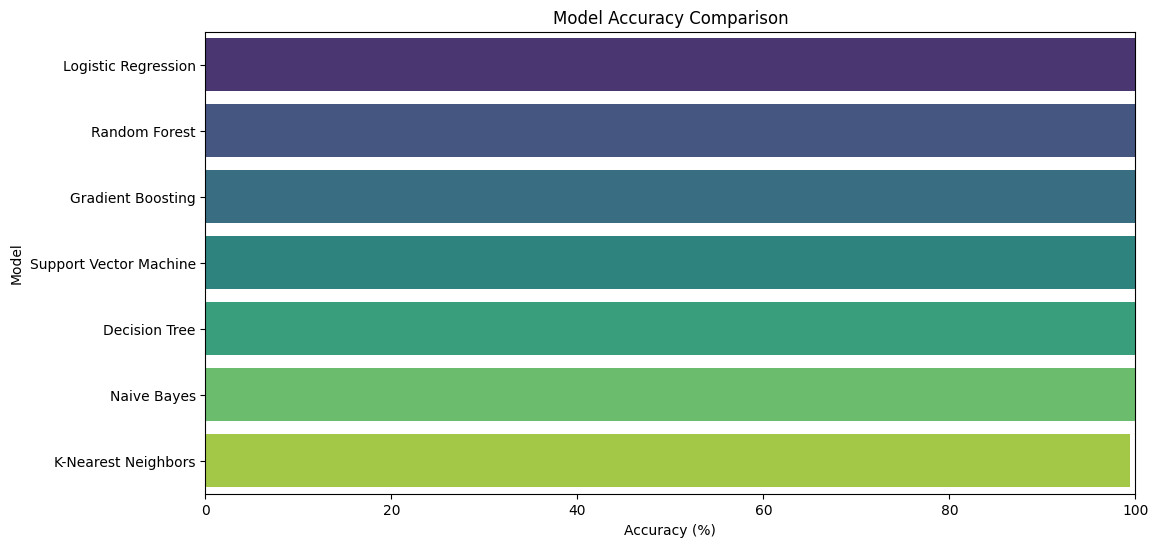

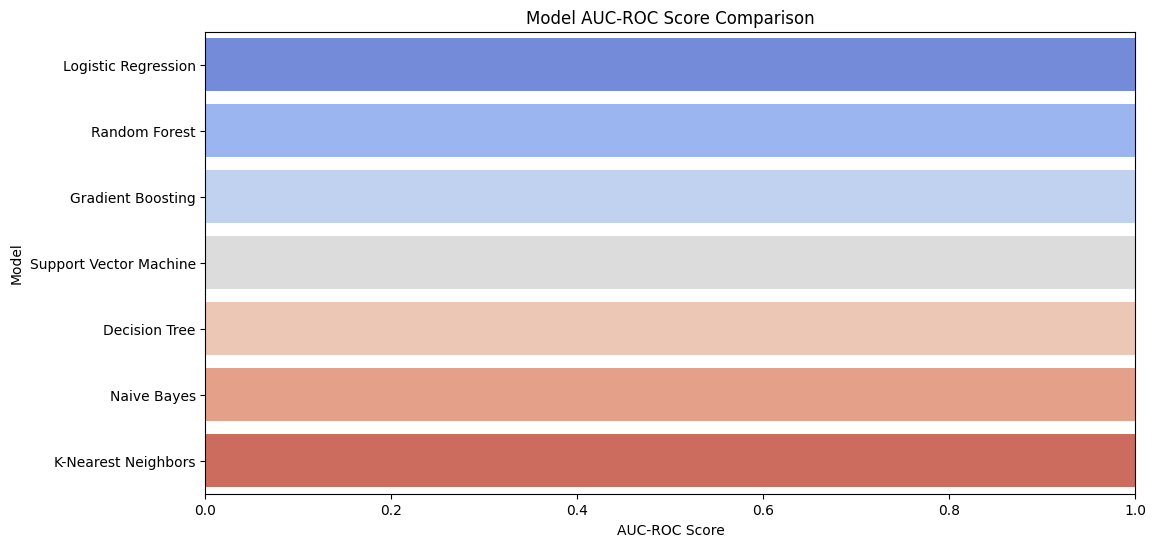

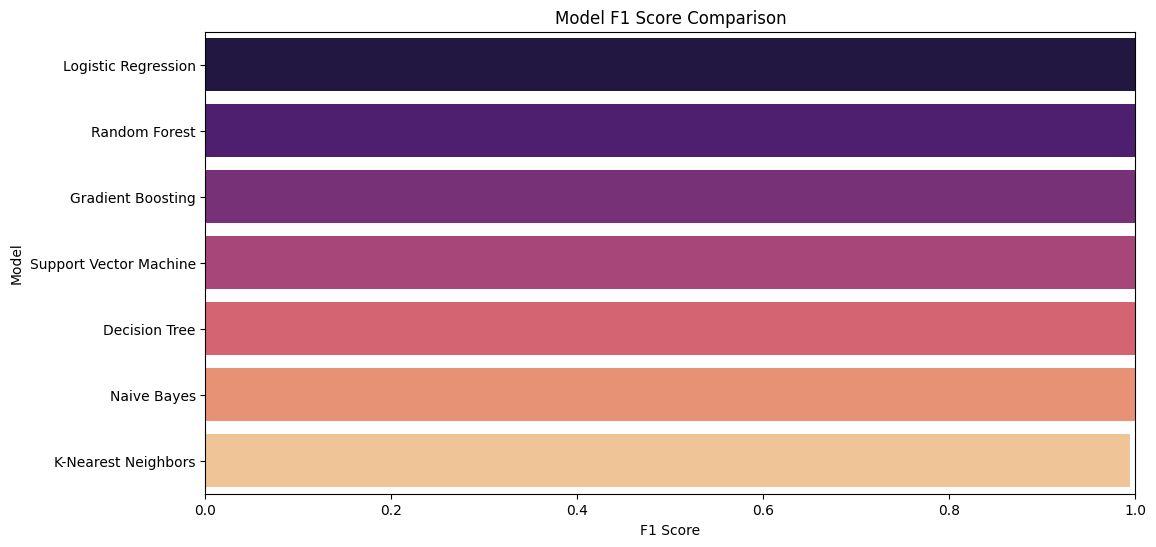

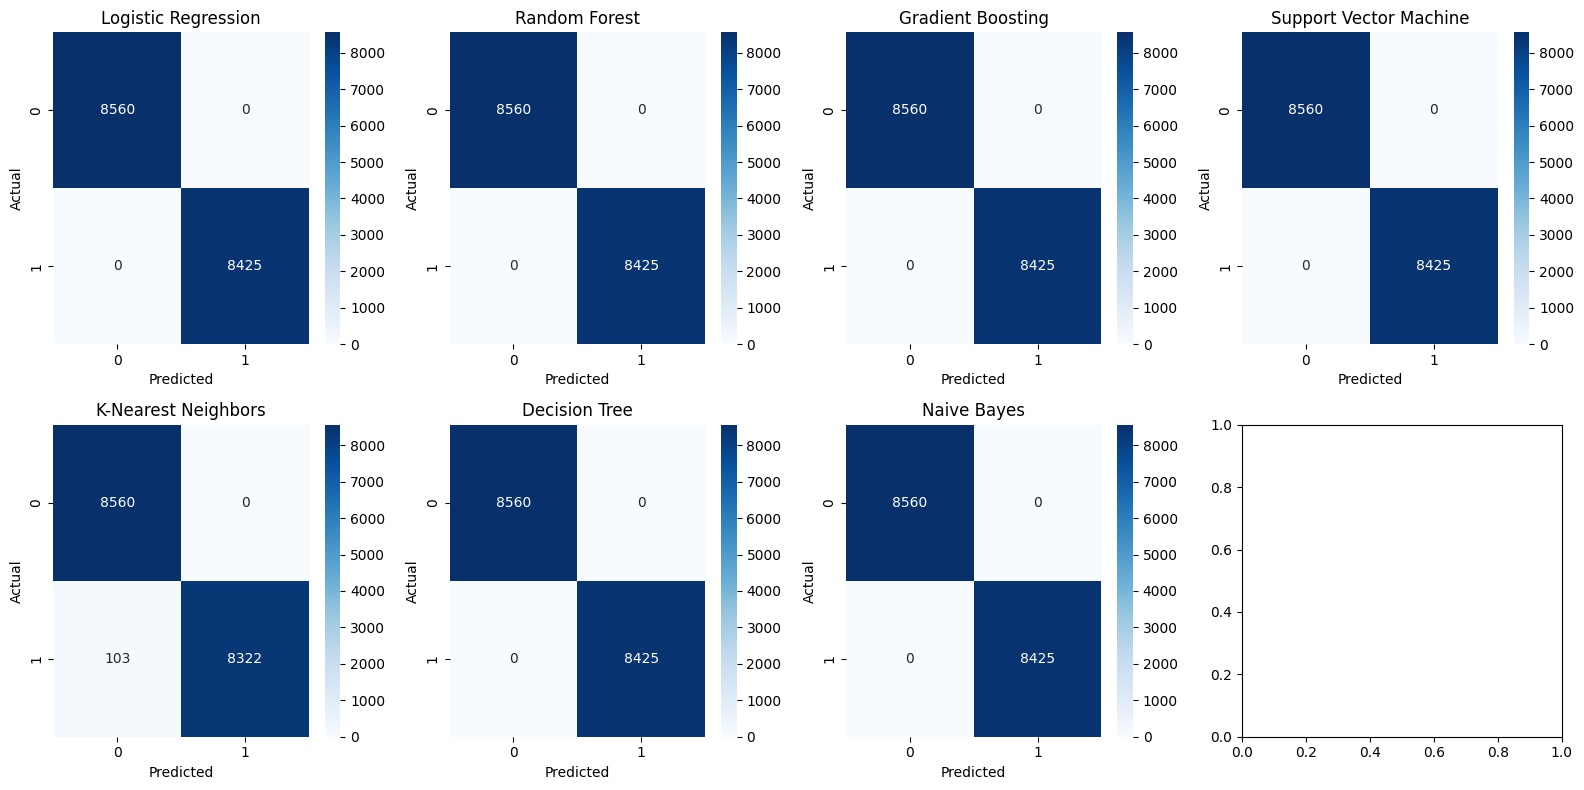

In [30]:
# Display accuracy of all models
results_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy (%)': results.values(),
    'AUC-ROC': auc_scores.values(),
    'F1 Score': f1_scores.values()
}).sort_values(by='Accuracy (%)', ascending=False)
print(results_df)

# Visualize accuracy
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy (%)', y='Model', data=results_df, palette='viridis')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 100)
plt.show()

# Visualize AUC-ROC Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='AUC-ROC', y='Model', data=results_df, palette='coolwarm')
plt.xlabel('AUC-ROC Score')
plt.ylabel('Model')
plt.title('Model AUC-ROC Score Comparison')
plt.xlim(0, 1)
plt.show()

# Visualize F1 Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='F1 Score', y='Model', data=results_df, palette='magma')
plt.xlabel('F1 Score')
plt.ylabel('Model')
plt.title('Model F1 Score Comparison')
plt.xlim(0, 1)
plt.show()

# Display confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Thank you!!!!!!!!!!!.....pls upvote...!!